# Step 1: Import Libraries and Load Dataset

In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [64]:
df = pd.read_csv("Clean_Dataset.csv")

df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


# Step 2: Understand Dataset

In [65]:
df.shape

(300153, 12)

In [66]:
df.columns

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [68]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


# Step 3: Check Missing Values

In [69]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

# Step 4: Drop Unnecessary Column

In [70]:
df.drop(["Unnamed: 0", "flight"], axis=1, inplace=True)

# Step 5: Exploratory Data Analysis (EDA)

### Price Distribution

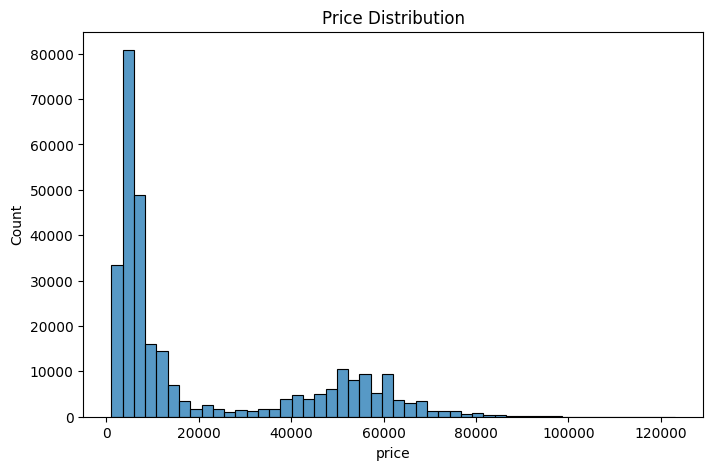

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=50)

plt.title("Price Distribution")
plt.show()

### Airline vs Price

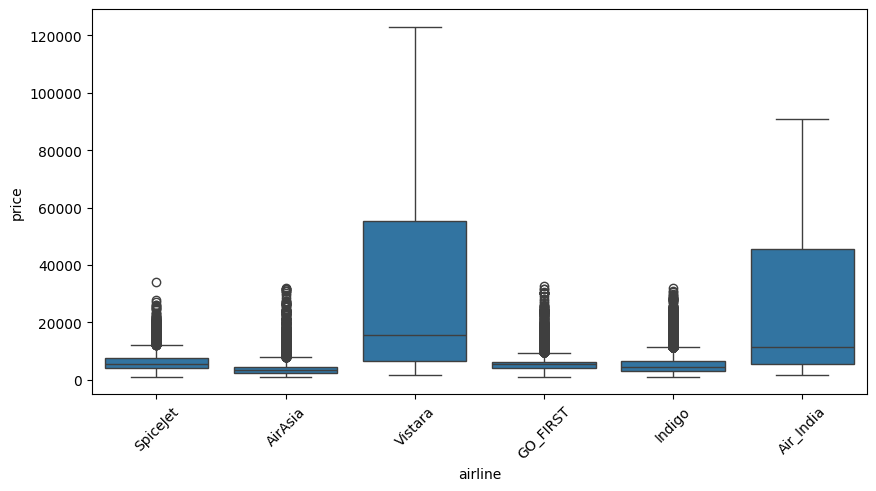

In [72]:
plt.figure(figsize=(10,5))

sns.boxplot(x="airline", y="price", data=df)

plt.xticks(rotation=45)

plt.show() #This shows which airlines have higher ticket prices.

### Stops vs Price

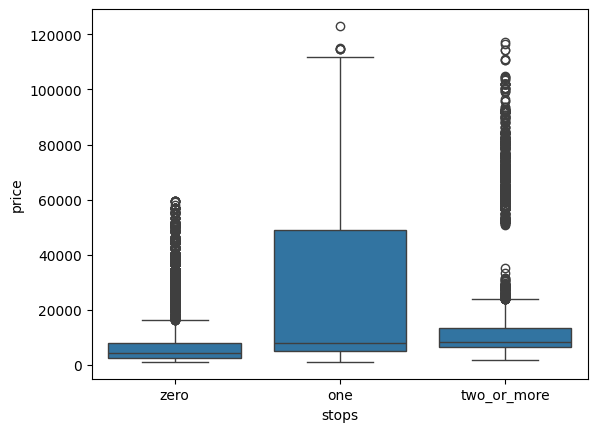

In [73]:
sns.boxplot(x="stops", y="price", data=df)

plt.show() #Flights with more stops usually cheaper.

# Step 6: Correlation Heatmap

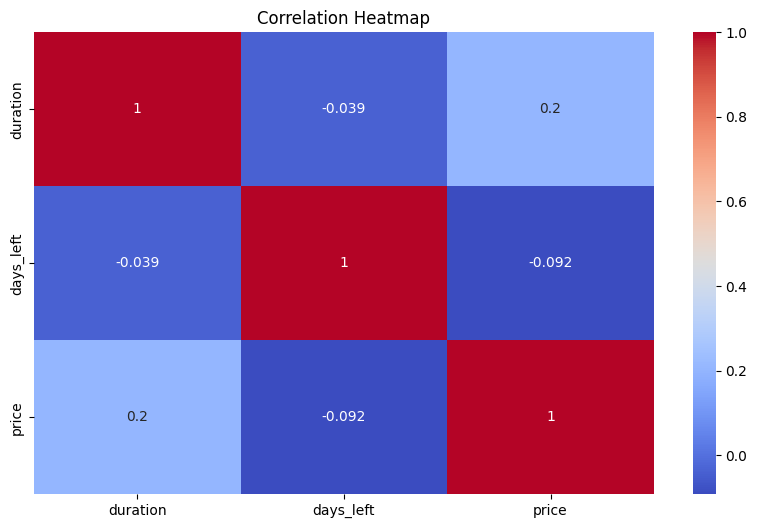

In [74]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Step 7: Convert Categorical Data

In [75]:
le = LabelEncoder()

categorical_columns = [
    "airline",
    "source_city",
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class"
]

for col in categorical_columns:
    
    df[col] = le.fit_transform(df[col])

# Step 8: Define Features and Target

In [76]:
X = df.drop("price", axis=1)

y = df["price"]

# Step 9: Train Test Split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 10: Train Models

### Linear Regression

In [78]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

### Decision Tree

In [79]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

### Random Forest

In [80]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

# Step 11: Evaluate Models

In [81]:
def evaluate(y_test, predictions):

    print("MAE:", mean_absolute_error(y_test, predictions))
    
    print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
    
    print("R2 Score:", r2_score(y_test, predictions))

### Evaluate Linear Regression

In [82]:
evaluate(y_test, lr_pred)

MAE: 4624.994868017008
RMSE: 7014.309680483318
R2 Score: 0.904554350718816


### Evaluate Decision Tree

In [83]:
evaluate(y_test, dt_pred)

MAE: 1173.7735503323283
RMSE: 3544.064079630467
R2 Score: 0.975633710712171


### Evaluate Random Forest

In [84]:
evaluate(y_test, rf_pred)

MAE: 1089.9931666402254
RMSE: 2781.911148910885
R2 Score: 0.9849868171278625


# Step 12: Model Comparison Plot

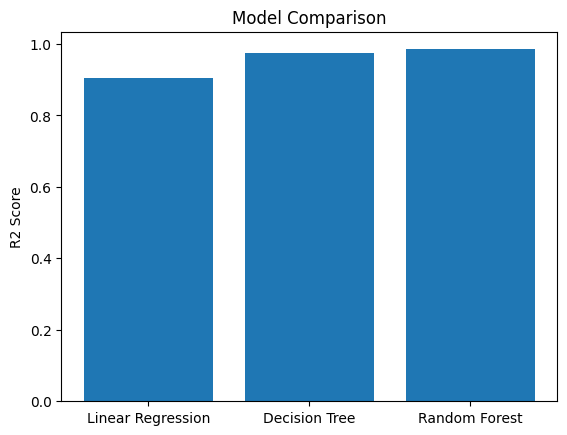

In [85]:
models = ["Linear Regression","Decision Tree","Random Forest"]

scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred)
]

plt.bar(models, scores)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()

# Step 13: Feature Importance

In [86]:
importance = rf.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    
    "Feature": feature_names,
    "Importance": importance
})

feature_df = feature_df.sort_values(by="Importance", ascending=False)

### Plot Feature Importance

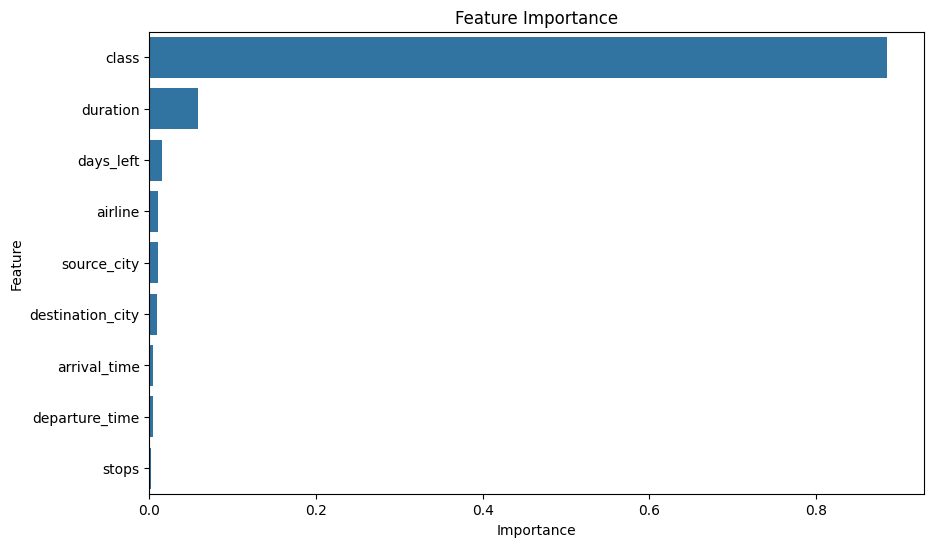

In [87]:
plt.figure(figsize=(10,6))

sns.barplot(x="Importance", y="Feature", data=feature_df)

plt.title("Feature Importance")

plt.show()

# Step 14: Actual vs Predicted Plot

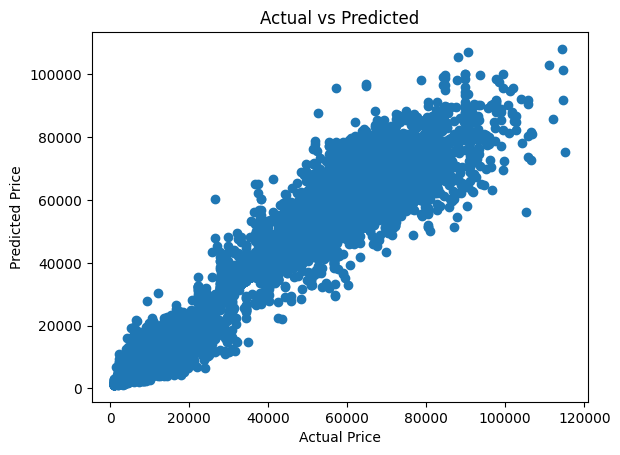

In [88]:
plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

#  Step 15: Save Model

In [89]:
import joblib

joblib.dump(rf, "airline_price_model.pkl", compress=3)

['airline_price_model.pkl']